# Milky Way Spiral Arms (SpiralMap)

Visualise spiral arm models from the SpiralMap package, focusing on Drimmel et al. (2024) Cepheid-traced arms.
The goal is to understand the spiral arm geometry relevant for the Cepheid distance prior.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from SpiralMap.models_ import main_, spiral_drimmel_cepheids, reid_spiral

R_sun = 8.122  # Solar galactocentric distance [kpc] (matching our model)

## Available models

In [14]:
sp = main_(Rsun=R_sun, print_=True)

try self.getinfo(model) for more details
+----+----------------------------+---------------------------+
|    | Available models & maps:   | Description               |
|----+----------------------------+---------------------------|
|  0 | Taylor_Cordes_1992         | HII                       |
|  1 | Vallee_1995                | Bfield/Dust/gas           |
|  2 | Drimmel_NIR_2000           | NIR emission              |
|  3 | Levine_2006                | HI                        |
|  4 | Hou_Han_2014               | HII/GMC/Masers            |
|  5 | Hou_Han_HII_2014           | HII                       |
|  6 | Reid_2019                  | MASER parallax            |
|  7 | Poggio_cont_2021           | Upper main sequence (map) |
|  8 | GaiaPVP_cont_2022          | OB stars (map)            |
|  9 | Drimmel_Ceph_2024          | Cepheids                  |
+----+----------------------------+---------------------------+


## Drimmel et al. (2024) Cepheid spiral arms

4 arms traced directly by 2857 dynamically young classical Cepheids with WISE mid-IR distances.
Uses log-periodic spirals: $\ln R = \ln R_0 - \tan(\psi) \cdot \phi$.

In [15]:
sp.getinfo(model='Drimmel_Ceph_2024')

#####################
Model = Drimmel_Ceph_2024
+----+------------+----------+
|    | Arm list   | Colour   |
|----+------------+----------|
|  0 | Scutum     | C3       |
|  1 | Sag-Car    | C0       |
|  2 | Orion      | C1       |
|  3 | Perseus    | C2       |
+----+------------+----------+


In [16]:
# Initialize Drimmel Cepheid model and print arm parameters
drimmel = spiral_drimmel_cepheids()
drimmel.xsun = -R_sun
drimmel.getarmlist()

# Extract parameters from the internal pickle data
spirals_data = drimmel.spirals
print(f"{'Arm':<12} {'pitch (strength)':>17} {'pitch (prom)':>13} {'ln R0 (strength)':>17} {'ln R0 (prom)':>13}")
print("-" * 75)
for arm in drimmel.arms:
    attr = spirals_data['1']['arm_attributes'][arm]
    print(f"{arm:<12} {attr['arm_pang_strength']:17.2f} {attr['arm_pang_prom']:13.2f} "
          f"{attr['arm_lgr0_strength']:17.3f} {attr['arm_lgr0_prom']:13.3f}")
    
print(f"\nPhi range: {spirals_data['1']['phi_range']} deg")

Arm           pitch (strength)  pitch (prom)  ln R0 (strength)  ln R0 (prom)
---------------------------------------------------------------------------
Scutum                   10.20         10.60             1.556         1.552
Sag-Car                  14.50         14.80             1.997         1.996
Orion                    16.00         15.60             2.244         2.250
Perseus                  22.00         20.90             2.459         2.477

Phi range: [-90.   0.] deg


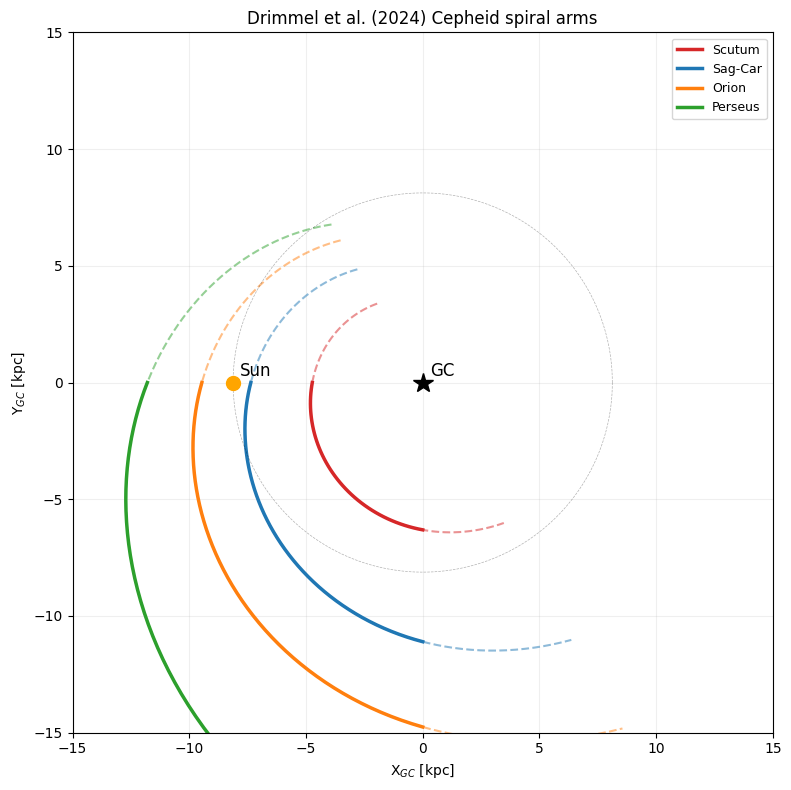

In [17]:
# Face-on view (Galactocentric)
fig, ax = plt.subplots(figsize=(8, 8))

for arm in drimmel.arms:
    drimmel.output_(arm)
    ax.plot(drimmel.dout['xgc'], drimmel.dout['ygc'],
            color=drimmel.armcolour[arm], lw=2.5, label=arm)
    # Extrapolated arms (dashed)
    if 'xgc_ex' in drimmel.dout:
        ax.plot(drimmel.dout['xgc_ex'], drimmel.dout['ygc_ex'],
                color=drimmel.armcolour[arm], lw=1.5, ls='--', alpha=0.5)

# Sun and GC
ax.plot(0, 0, 'k*', ms=15, zorder=10)
ax.annotate('GC', (0.3, 0.3), fontsize=12)
ax.plot(-R_sun, 0, 'o', color='orange', ms=10, zorder=10)
ax.annotate('Sun', (-R_sun + 0.3, 0.3), fontsize=12)

# Circle at solar radius
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(R_sun * np.cos(theta), R_sun * np.sin(theta), 'k--', lw=0.5, alpha=0.3)

ax.set_xlabel('X$_{GC}$ [kpc]')
ax.set_ylabel('Y$_{GC}$ [kpc]')
ax.set_title('Drimmel et al. (2024) Cepheid spiral arms')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-15, 15)
ax.set_ylim(-15, 15)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

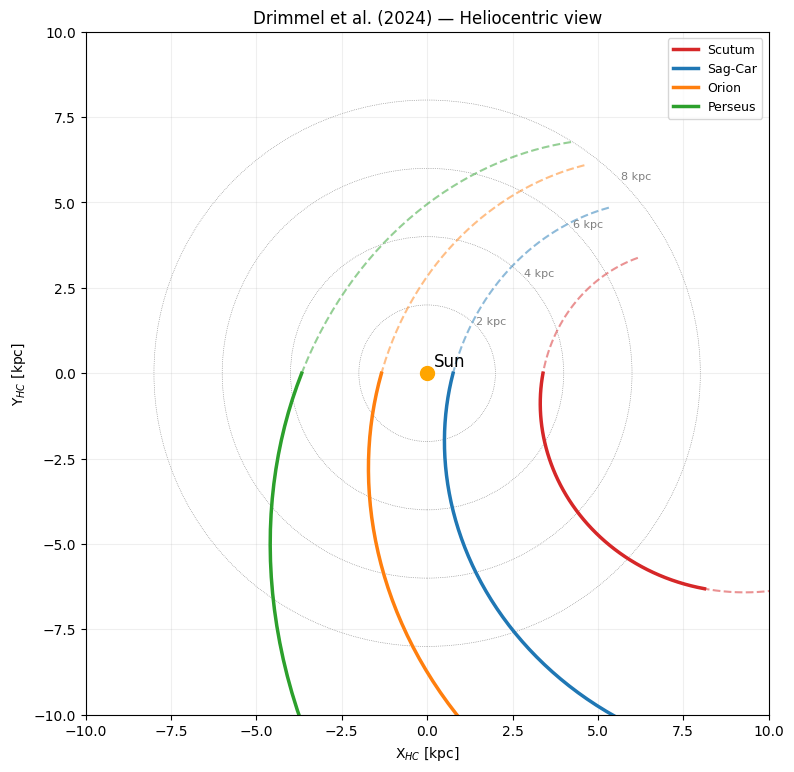

In [18]:
# Face-on view (Heliocentric) — zoomed to C22 star distances
fig, ax = plt.subplots(figsize=(8, 8))

for arm in drimmel.arms:
    drimmel.output_(arm)
    ax.plot(drimmel.dout['xhc'], drimmel.dout['yhc'],
            color=drimmel.armcolour[arm], lw=2.5, label=arm)
    if 'xhc_ex' in drimmel.dout:
        ax.plot(drimmel.dout['xhc_ex'], drimmel.dout['yhc_ex'],
                color=drimmel.armcolour[arm], lw=1.5, ls='--', alpha=0.5)

ax.plot(0, 0, 'o', color='orange', ms=10, zorder=10)
ax.annotate('Sun', (0.2, 0.2), fontsize=12)

# Distance circles from Sun
for r in [2, 4, 6, 8]:
    circle = plt.Circle((0, 0), r, fill=False, ls=':', color='grey', lw=0.5)
    ax.add_patch(circle)
    ax.annotate(f'{r} kpc', (r * 0.71, r * 0.71), fontsize=8, color='grey')

ax.set_xlabel('X$_{HC}$ [kpc]')
ax.set_ylabel('Y$_{HC}$ [kpc]')
ax.set_title('Drimmel et al. (2024) — Heliocentric view')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Arm width and density profile

Reid et al. (2019) find arm width grows with radius:
$w(R) = 0.336 + 0.036 \times (R - 8.15)$ kpc.
Drimmel et al. (2024) don't provide explicit widths, so we use Reid's relation as a reference.

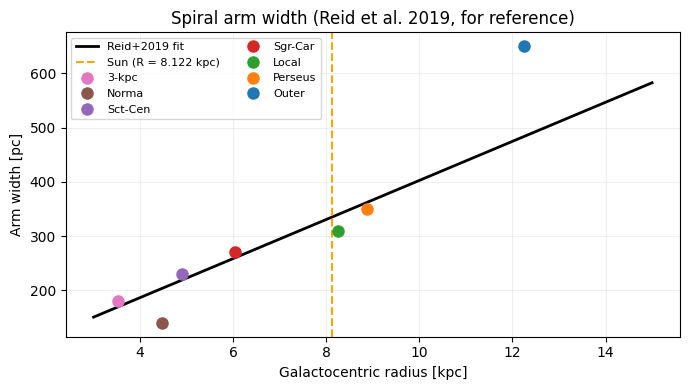

In [19]:
# Arm width as a function of R (from Reid et al. 2019 — used as reference)
reid = reid_spiral()
reid.xsun = -R_sun

R_grid = np.linspace(3, 15, 100)
w_grid = 0.336 + 0.036 * (R_grid - 8.15)  # kpc

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(R_grid, w_grid * 1000, 'k-', lw=2, label='Reid+2019 fit')
ax.axvline(R_sun, color='orange', ls='--', label=f'Sun (R = {R_sun} kpc)')

# Plot individual arm widths from Reid 2019
for arm in reid.arms:
    p = reid.getparams(arm)
    ax.plot(p['R_kink'], p['width'] * 1000, 'o',
            color=reid.armcolour[arm], ms=8, label=arm)

ax.set_xlabel('Galactocentric radius [kpc]')
ax.set_ylabel('Arm width [pc]')
ax.set_title('Spiral arm width (Reid et al. 2019, for reference)')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Distance to nearest arm along sightlines

For each (ell, d), compute the minimum perpendicular distance to any Drimmel (2024) arm.
This shows which sightlines pass through spiral arms at which distances.

In [20]:
def ell_d_to_galactocentric(ell_deg, d_kpc, R_sun=8.122):
    """Convert (ell, d) in the plane (b=0) to Galactocentric (x, y)."""
    ell_rad = np.deg2rad(ell_deg)
    x_hc = d_kpc * np.cos(ell_rad)
    y_hc = d_kpc * np.sin(ell_rad)
    x_gc = x_hc - R_sun
    y_gc = y_hc
    return x_gc, y_gc


def min_distance_to_arms(x_gc, y_gc, model):
    """Minimum distance from (x_gc, y_gc) to any arm trace (uses extrapolated)."""
    min_dist = np.full_like(x_gc, np.inf)
    for arm in model.arms:
        model.output_(arm)
        # Use extrapolated trace if available for better coverage
        xkey = 'xgc_ex' if 'xgc_ex' in model.dout else 'xgc'
        ykey = 'ygc_ex' if 'ygc_ex' in model.dout else 'ygc'
        xa = model.dout[xkey]
        ya = model.dout[ykey]
        # Vectorised: distance from each query point to closest arm point
        for i in range(len(x_gc.ravel())):
            d = np.sqrt((xa - x_gc.ravel()[i])**2 + (ya - y_gc.ravel()[i])**2)
            dmin = np.nanmin(d)
            if dmin < min_dist.ravel()[i]:
                min_dist.ravel()[i] = dmin
    return min_dist


# Grid in (ell, d)
ell_arr = np.linspace(0, 360, 181)
d_arr = np.linspace(0.1, 8, 80)
ell_mesh, d_mesh = np.meshgrid(ell_arr, d_arr)

x_gc, y_gc = ell_d_to_galactocentric(ell_mesh, d_mesh, R_sun=R_sun)
dist_to_arm = min_distance_to_arms(x_gc, y_gc, drimmel)

print(f"Grid computed: {ell_mesh.shape}")

Grid computed: (80, 181)


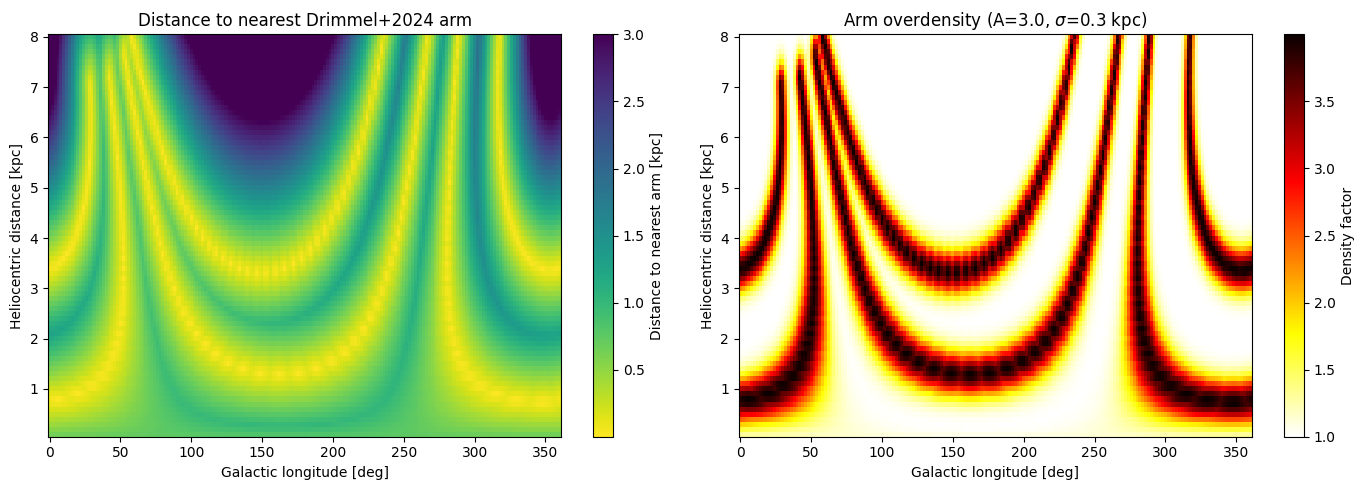

In [21]:
# Density factor: Gaussian overdensity near arms
# Using a fixed width sigma = 0.3 kpc as illustration
sigma_arm = 0.3  # kpc
A_arm = 3.0  # arm/inter-arm contrast (Cepheids strongly trace arms)
density_factor = 1 + A_arm * np.exp(-0.5 * (dist_to_arm / sigma_arm)**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance to nearest arm
ax = axes[0]
im = ax.pcolormesh(ell_arr, d_arr, dist_to_arm, cmap='viridis_r', vmax=3)
plt.colorbar(im, ax=ax, label='Distance to nearest arm [kpc]')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Heliocentric distance [kpc]')
ax.set_title('Distance to nearest Drimmel+2024 arm')

# Density factor
ax = axes[1]
im = ax.pcolormesh(ell_arr, d_arr, density_factor, cmap='hot_r')
plt.colorbar(im, ax=ax, label='Density factor')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Heliocentric distance [kpc]')
ax.set_title(f'Arm overdensity (A={A_arm}, $\\sigma$={sigma_arm} kpc)')

plt.tight_layout()
plt.show()

## Overlay C22 Cepheid positions

In [22]:
import sys
sys.path.insert(0, "..")
from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config

cfg = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))

import copy
cfg_all = copy.deepcopy(cfg)
cfg_all["data"].pop("which_subset", None)
data_all = CepheidData(cfg_all)
campaigns = data_all.split_by_campaign()

2026-02-11 12:43:39 ============================================================
2026-02-11 12:43:39 Model Configuration
2026-02-11 12:43:39 ============================================================
2026-02-11 12:43:39   Model type      : forward
2026-02-11 12:43:39   Distance prior  : disk
2026-02-11 12:43:39 ------------------------------------------------------------
2026-02-11 12:43:39 C22 Selection
2026-02-11 12:43:39 ------------------------------------------------------------
2026-02-11 12:43:39   mW selection    : ENABLED
2026-02-11 12:43:39   mW_max          : 7.500
2026-02-11 12:43:39   mW_width        : 0.500
2026-02-11 12:43:39   AH selection    : disabled
2026-02-11 12:43:39   pi selection    : ENABLED
2026-02-11 12:43:39   pi_min          : 0.350
2026-02-11 12:43:39   pi_smooth       : True
2026-02-11 12:43:39   pi_width        : 0.1
2026-02-11 12:43:39   Distance grid   : [0.1, 8.0] kpc, n=159, dx=0.05
2026-02-11 12:43:39   MC selection    : 500
2026-02-11 12:43:39   

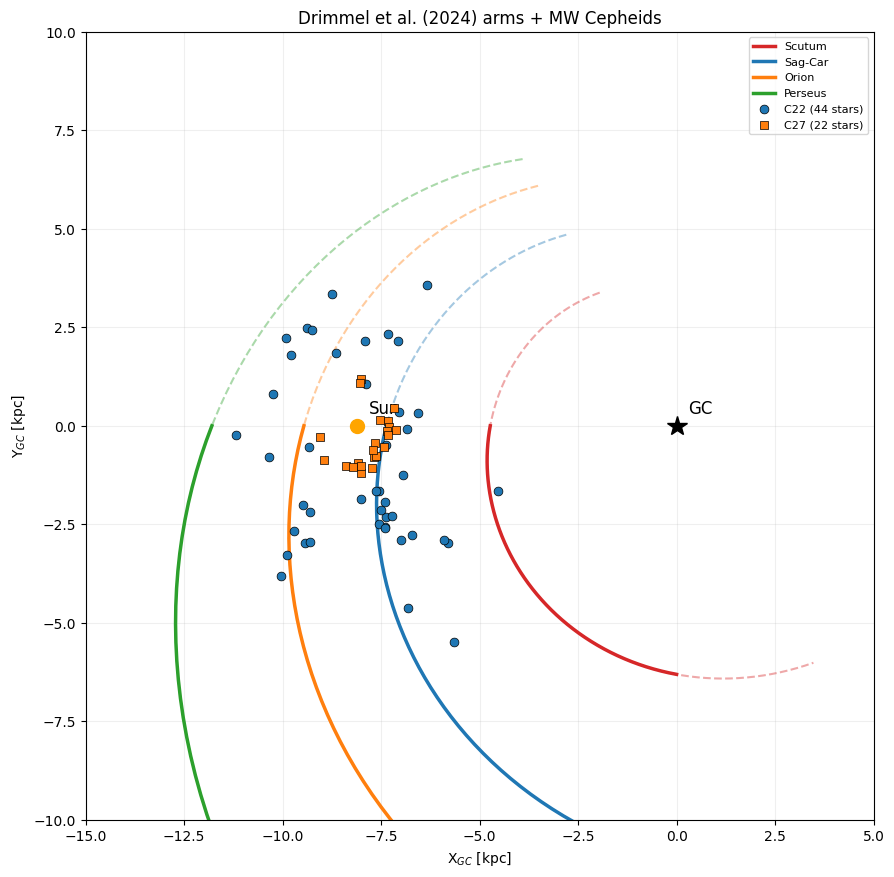

In [23]:
# Face-on plot with Cepheids
delta_pi = -0.014  # parallax zero-point offset

fig, ax = plt.subplots(figsize=(9, 9))

# Plot Drimmel spiral arms
for arm in drimmel.arms:
    drimmel.output_(arm)
    ax.plot(drimmel.dout['xgc'], drimmel.dout['ygc'],
            color=drimmel.armcolour[arm], lw=2.5, label=arm)
    if 'xgc_ex' in drimmel.dout:
        ax.plot(drimmel.dout['xgc_ex'], drimmel.dout['ygc_ex'],
                color=drimmel.armcolour[arm], lw=1.5, ls='--', alpha=0.4)

# Plot Cepheids
markers = {'C22': 'o', 'C27': 's'}
for name, d in campaigns.items():
    ell_c = np.asarray(d.ell)
    b_c = np.asarray(d.b)
    pi_c = np.asarray(d.pi_EDR3)
    d_c = 1.0 / (pi_c - delta_pi)

    ell_rad = np.deg2rad(ell_c)
    b_rad = np.deg2rad(b_c)
    x_hc = d_c * np.cos(b_rad) * np.cos(ell_rad)
    y_hc = d_c * np.cos(b_rad) * np.sin(ell_rad)
    x_gc = x_hc - R_sun
    y_gc = y_hc

    ax.scatter(x_gc, y_gc, marker=markers[name], s=40, edgecolor='k',
               lw=0.5, label=f'{name} ({len(ell_c)} stars)', zorder=10)

# Sun and GC
ax.plot(0, 0, 'k*', ms=15, zorder=10)
ax.annotate('GC', (0.3, 0.3), fontsize=12)
ax.plot(-R_sun, 0, 'o', color='orange', ms=10, zorder=10)
ax.annotate('Sun', (-R_sun + 0.3, 0.3), fontsize=12)

ax.set_xlabel('X$_{GC}$ [kpc]')
ax.set_ylabel('Y$_{GC}$ [kpc]')
ax.set_title('Drimmel et al. (2024) arms + MW Cepheids')
ax.set_aspect('equal')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(-15, 5)
ax.set_ylim(-10, 10)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

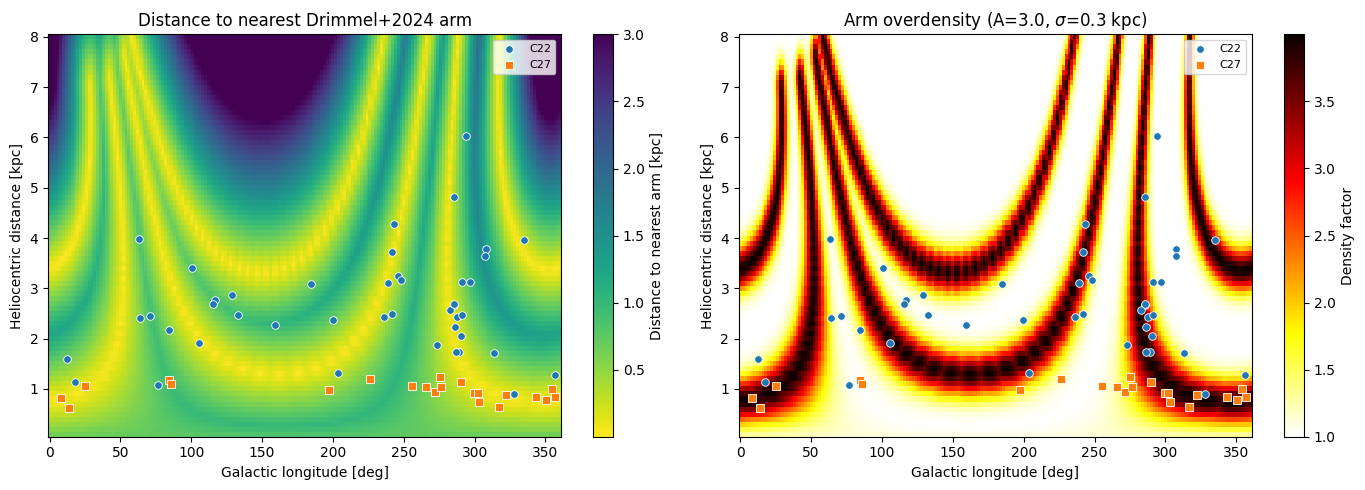

In [24]:
# Overlay Cepheids on the (ell, d) density-factor map
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distance to nearest arm
ax = axes[0]
im = ax.pcolormesh(ell_arr, d_arr, dist_to_arm, cmap='viridis_r', vmax=3)
plt.colorbar(im, ax=ax, label='Distance to nearest arm [kpc]')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Heliocentric distance [kpc]')
ax.set_title('Distance to nearest Drimmel+2024 arm')

# Density factor
ax = axes[1]
im = ax.pcolormesh(ell_arr, d_arr, density_factor, cmap='hot_r')
plt.colorbar(im, ax=ax, label='Density factor')
ax.set_xlabel('Galactic longitude [deg]')
ax.set_ylabel('Heliocentric distance [kpc]')
ax.set_title(f'Arm overdensity (A={A_arm}, $\\sigma$={sigma_arm} kpc)')

# Overplot Cepheids on both panels
markers = {'C22': 'o', 'C27': 's'}
for ax in axes:
    for name, d in campaigns.items():
        ell_c = np.asarray(d.ell)
        pi_c = np.asarray(d.pi_EDR3)
        d_c = 1.0 / (pi_c - delta_pi)
        ax.scatter(ell_c, d_c, marker=markers[name], s=30, edgecolor='white',
                   lw=0.6, label=f'{name}', zorder=10)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## Compare models: Reid 2019 vs Hou & Han 2014 vs Drimmel Cepheids 2024

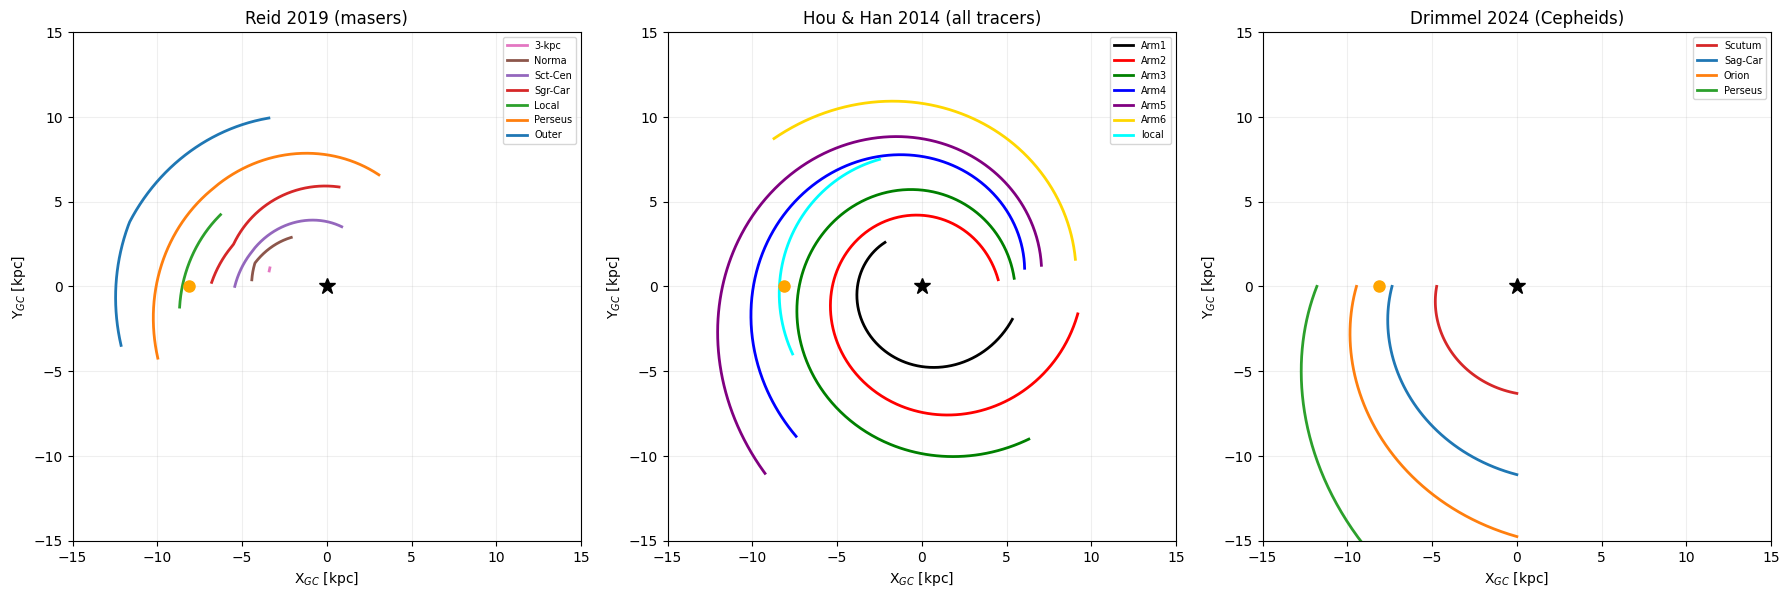

In [25]:
from SpiralMap.models_ import reid_spiral, spiral_houhan, spiral_drimmel_cepheids

models = {
    'Reid 2019 (masers)': reid_spiral(),
    'Hou & Han 2014 (all tracers)': spiral_houhan(),
    'Drimmel 2024 (Cepheids)': spiral_drimmel_cepheids(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (title, mod) in zip(axes, models.items()):
    mod.xsun = -R_sun
    mod.getarmlist()

    for arm in mod.arms:
        mod.output_(arm)
        ax.plot(mod.dout['xgc'], mod.dout['ygc'],
                color=mod.armcolour[arm], lw=2, label=arm)

    ax.plot(0, 0, 'k*', ms=12)
    ax.plot(-R_sun, 0, 'o', color='orange', ms=8)
    ax.set_xlabel('X$_{GC}$ [kpc]')
    ax.set_ylabel('Y$_{GC}$ [kpc]')
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()